In [ ]:
# Import packages
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Paths for training and holdout datasets
REPO_ROOT = Path(__file__).resolve().parent.parent    
X_TRAIN_CSV = REPO_ROOT / "Datasets" / "X_train.csv"
X_TEST_PSI_CSV = REPO_ROOT / "Datasets" / "X_test_psi.csv"

In [ ]:
# Import X_test_psi to analyse distribution
psi_df = pd.read_csv(X_TEST_PSI_CSV)
train_df = pd.read_csv(X_TRAIN_CSV)

In [ ]:
# Combined datasets for plotting
psi_df['dataset'] = 'X_test_psi'
train_df['dataset'] = 'X_train'
combined_df = pd.concat([train_df, psi_df], ignore_index=True)

,revenue,dti_n,loan_amnt,fico_n,purpose,home_ownership_n,emp_length,experience_c,addr_state,zip_code,title,unemployment_rate,credit_spread,dataset
0,42000.0,32.69,9250,662.0,debt_consolidation,MORTGAGE,6 years,1,FL,347xx,repayment,7.5,2.740455,X_train
1,210000.0,12.08,30000,682.0,credit_card,MORTGAGE,8 years,1,UT,840xx,Credit card refinancing,4.8,2.683913,X_train
2,45000.0,15.09,10000,697.0,debt_consolidation,RENT,2 years,1,MN,551xx,Debt consolidation,5.4,2.549091,X_train
3,125000.0,3.61,15000,727.0,debt_consolidation,MORTGAGE,3 years,1,AL,368xx,Debt consolidation,5.1,3.168095,X_train
4,27900.0,17.16,9450,717.0,debt_consolidation,MORTGAGE,NI,1,NC,281xx,debt consolidation,7.7,2.897000,X_train


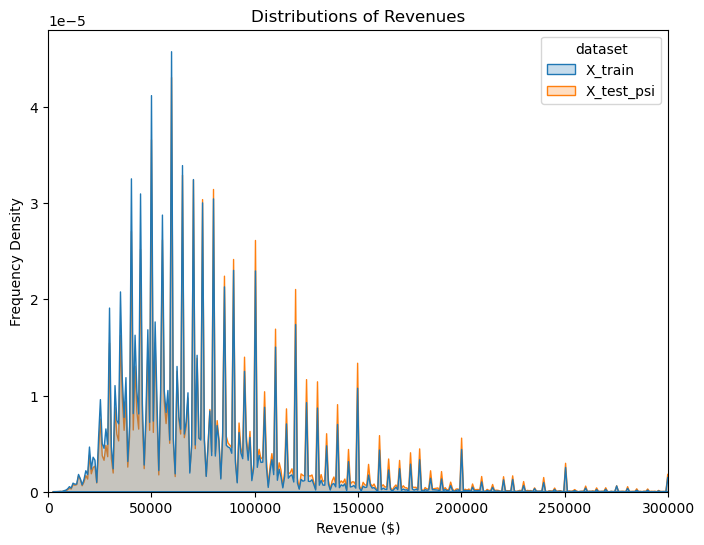

In [29]:
# Analyse distributions of revenue
plt.figure(figsize=(8, 6))
revenue_dist = sns.histplot(data=combined_df, x='revenue', stat='density', element='poly', hue='dataset', common_norm=False)

plt.title('Distributions of Revenues')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency Density')
plt.xlim((0, 300000))
plt.show()

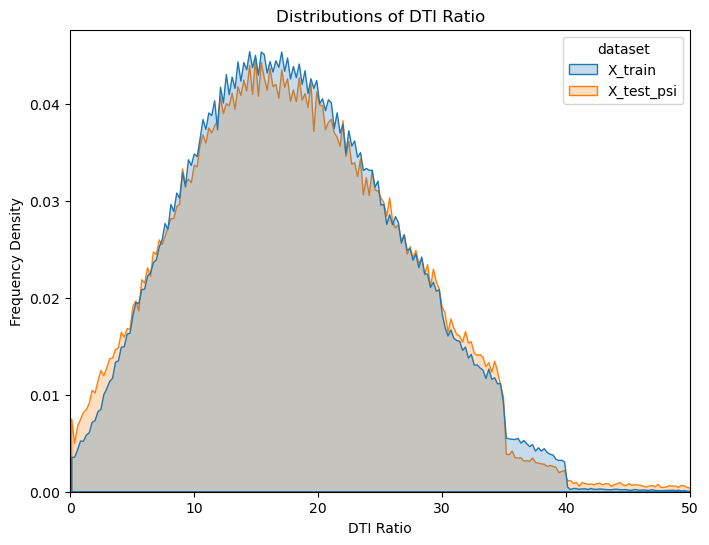

In [32]:
# Analyse distributions of debt-to-income ratio
plt.figure(figsize=(8, 6))
dti_dist = sns.histplot(data=combined_df, x='dti_n', stat='density', element='poly', hue='dataset', common_norm=False)

plt.title('Distributions of DTI Ratio')
plt.xlabel('DTI Ratio')
plt.ylabel('Frequency Density')
plt.xlim((0, 50))
plt.show()

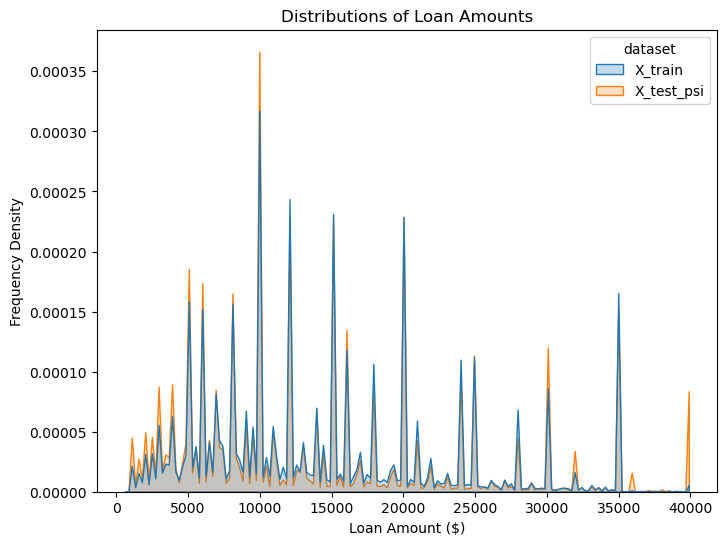

In [ ]:
# Analyse distributions of loan amount
plt.figure(figsize=(8, 6))
loan_amount_dist = sns.histplot(data=combined_df, x='loan_amnt', stat='density', element='poly', hue='dataset', common_norm=False)

plt.title('Distributions of Loan Amounts')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency Density')
plt.show()

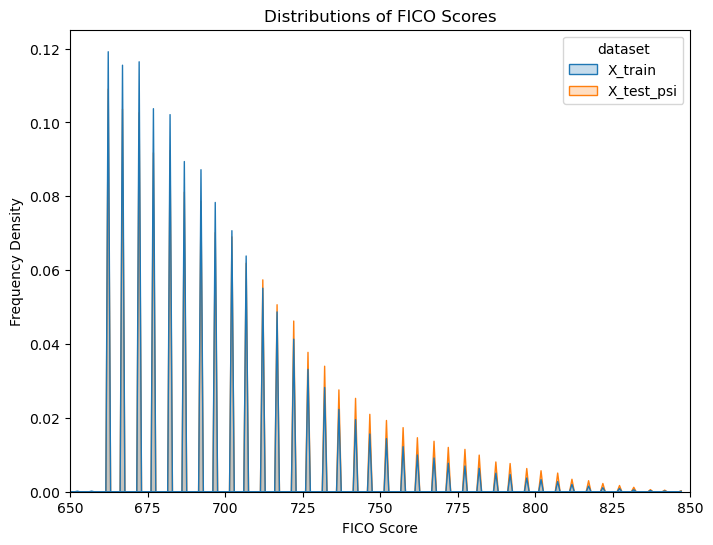

In [35]:
# Analyse distributions of FICO score
plt.figure(figsize=(8, 6))
loan_amount_dist = sns.histplot(data=combined_df, x='fico_n', stat='density', element='poly', hue='dataset', common_norm=False)

plt.title('Distributions of FICO Scores')
plt.xlabel('FICO Score')
plt.ylabel('Frequency Density')
plt.xlim((650, 850))
plt.show()

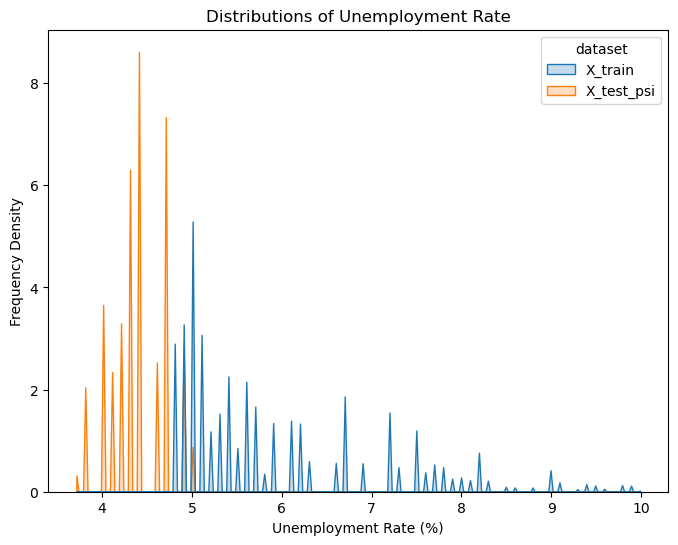

In [ ]:
# Analyse distributions of unemployment rate
plt.figure(figsize=(8, 6))
loan_amount_dist = sns.histplot(data=combined_df, x='unemployment_rate', stat='density', element='poly', hue='dataset', common_norm=False)

plt.title('Distributions of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency Density')
plt.show()

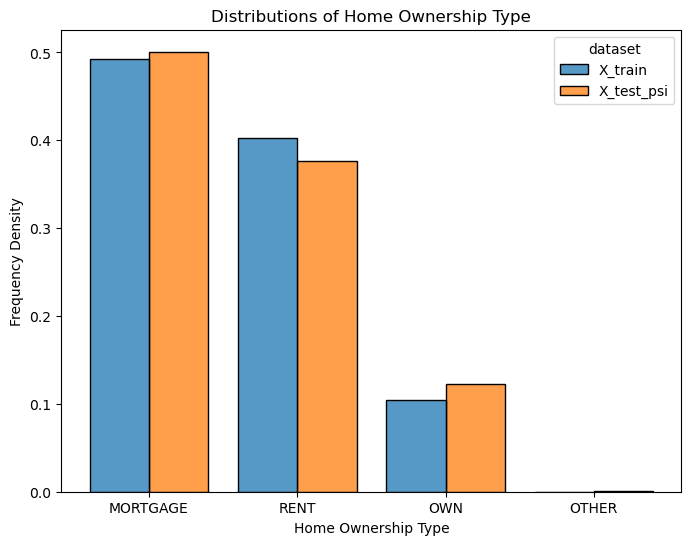

In [41]:
# Analyse distributions of home ownership type
plt.figure(figsize=(8, 6))
loan_amount_dist = sns.histplot(data=combined_df, x='home_ownership_n', stat='density', multiple='dodge', hue='dataset', shrink=0.8, common_norm=False)

plt.title('Distributions of Home Ownership Type')
plt.xlabel('Home Ownership Type')
plt.ylabel('Frequency Density')
plt.show()

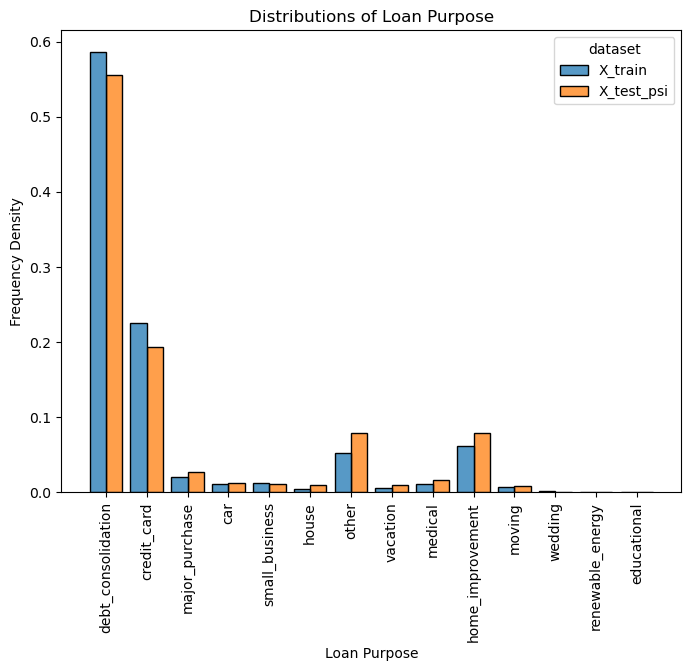

In [43]:
# Analyse distributions of home ownership type
plt.figure(figsize=(8, 6))
loan_amount_dist = sns.histplot(data=combined_df, x='purpose', stat='density', multiple='dodge', hue='dataset', shrink=0.8, common_norm=False)

plt.title('Distributions of Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Frequency Density')
plt.xticks(rotation=90)
plt.show()

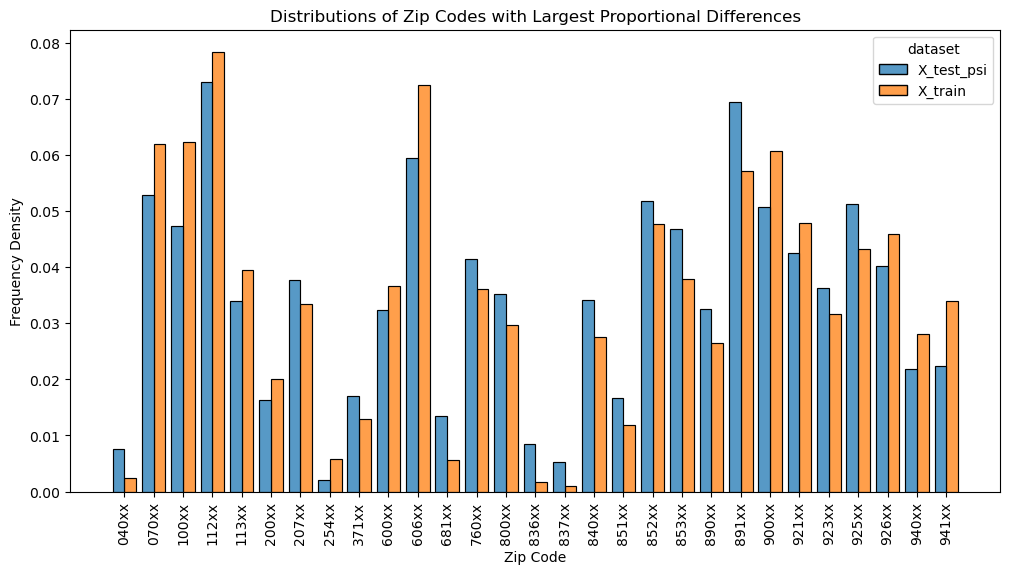

In [55]:
train_zip_props = combined_df.loc[combined_df['dataset'] == 'X_train', 'zip_code'].value_counts(normalize=True)
psi_zip_props = combined_df.loc[combined_df['dataset'] == 'X_test_psi', 'zip_code'].value_counts(normalize=True)
zip_props = pd.DataFrame({'X_train': train_zip_props, 'X_test_psi': psi_zip_props}).fillna(0)
different_zip_codes = zip_props.index[np.abs(zip_props['X_train'] - zip_props['X_test_psi']) > 0.0005]


# Analyse distributions of zip code
plt.figure(figsize=(12, 6))
loan_amount_dist = sns.histplot(data=combined_df[combined_df['zip_code'].isin(different_zip_codes)].sort_values(by='zip_code'), x='zip_code', stat='density', multiple='dodge', hue='dataset', shrink=0.8, common_norm=False)

plt.title('Distributions of Zip Codes with Largest Proportional Differences')
plt.xlabel('Zip Code')
plt.ylabel('Frequency Density')
plt.xticks(rotation=90)
plt.show()